<a href="https://colab.research.google.com/github/ParusSlava/melbourne-housing/blob/main/notebook/26_06_26_melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")


Бібліотеки готові ✅


## Крок 1. Завантаження даних

In [94]:
RAW_URL = 'https://raw.githubusercontent.com/ParusSlava/melbourne-housing/refs/heads/main/data/melb_data.csv'

df_origin = pd.read_csv(RAW_URL)

In [95]:
df = df_origin.copy()

## Крок 2. Перший огляд

In [96]:
print(df.shape)

(13580, 21)


In [97]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [98]:
# Типи стовпців
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [99]:
# пропуски: зробіть таблицю "скільки пропусків у кожному стовпці у відсотках"
df.isna().mean().round(2).sort_values(ascending=False)

,0
BuildingArea,0.47
YearBuilt,0.40
CouncilArea,0.10
Address,0.00
Suburb,0.00
Price,0.00
Type,0.00
Rooms,0.00
Method,0.00
Postcode,0.00


In [100]:
#  описова статистика чисел
df.describe().round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [101]:
print("Кількість нулів:\n", (df == 0).sum())
print("\nКількість NaN:\n", df.isna().sum())

Кількість нулів:
 Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            6
Postcode            0
Bedroom2           16
Bathroom           34
Car              1026
Landsize         1939
BuildingArea       17
YearBuilt           0
CouncilArea         0
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64

Кількість NaN:
 Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


## Крок 3. Очищення

In [102]:
# Робимо копію (захист оригіналу)
clean = df.copy()
print('Копію створено. Розмір:', clean.shape)

Копію створено. Розмір: (13580, 21)


In [103]:
# Перевіряємо технічний стовпець-індекс
clean = df.copy()
if 'Unnamed: 0' in df.columns:
    clean = clean.drop(columns = ['Unnamed: 0'])
    print('Column with index - deleted')


In [104]:
# Змінюємо тип даних в Даті (конвертуємо)
clean['Date'] = pd.to_datetime(clean['Date'], dayfirst = True)

#  Після конвертації
print("Тип після:", clean["Date"].dtype)


Тип після: datetime64[ns]


In [105]:
# Замінюємо нулі на "немає даних"

# 1. Дивимося скільки нулів у стовпцях до заміни
print("Нулів у стовпці 'Landsize'до:", (clean['Landsize'] == 0).sum())
print("Нулів у стовпці 'BuildingArea'до:", (clean['BuildingArea'] == 0).sum())

Нулів у стовпці 'Landsize'до: 1939
Нулів у стовпці 'BuildingArea'до: 17


In [106]:
# 2. Замінюємо 0 на NaN (справжнє "немає даних")
for col in ['Landsize', 'BuildingArea']:
    clean.loc[clean[col] == 0, col] = np.nan

# 3. Дивимося скільки нулів у стовпцях після заміни
print("\nНулів у стовпці 'Landsize' Після:", (clean['Landsize'] == 0).sum())
print("Нулів у стовпці 'BuildingArea' Після:", (clean['BuildingArea'] == 0).sum())


Нулів у стовпці 'Landsize' Після: 0
Нулів у стовпці 'BuildingArea' Після: 0


In [107]:
# Виправляємо неможливі роки побудови
# 1. Дивимося що є підозрілого
print('Мінімальний рік:', clean['YearBuilt'].min())
print('Максимальний рік:', clean['YearBuilt'].max())


Мінімальний рік: 1196.0
Максимальний рік: 2018.0


In [108]:
# Дивимося кількість підозрілих значень
print(clean[clean['YearBuilt'] < 1800]['YearBuilt'].value_counts())

YearBuilt
1196.0    1
Name: count, dtype: int64


In [109]:
# Змінюємо підозрілі значення на NaN
clean.loc[clean['YearBuilt'] < 1800, 'YearBuilt'] = np.nan

In [110]:
# Дивимося мінімальний рік після заміни
print("\nМінімальні роки 'YearBuilt' після заміни", (clean['YearBuilt']).min())


Мінімальні роки 'YearBuilt' після заміни 1830.0


In [111]:
# Перевіряємо чи є дублікати
clean.duplicated().sum()

np.int64(0)

In [112]:
# Перевіряємо розмір після очищення даних
clean.shape

(13580, 21)

## Крок 4. Дослідження (EDA)

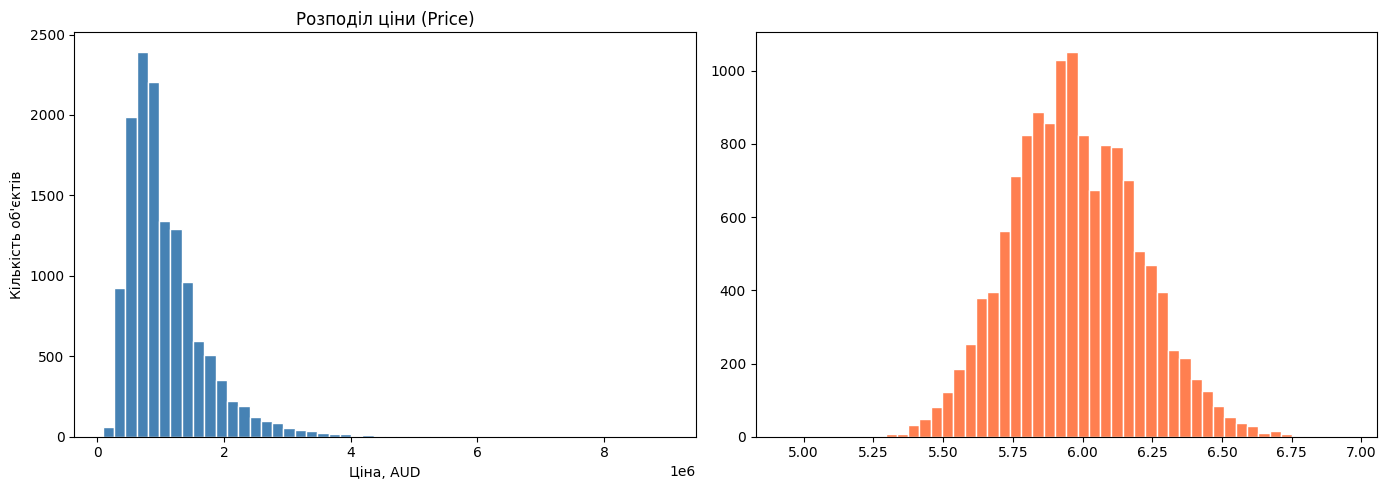

In [113]:
# Робимо графік розподілу ціни
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["Price"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Розподіл ціни (Price)")
axes[0].set_xlabel("Ціна, AUD")
axes[0].set_ylabel("Кількість об'єктів")
axes[1].hist(np.log10(df["Price"].dropna()), bins=50, color="coral", edgecolor="white")
plt.tight_layout()
plt.show()

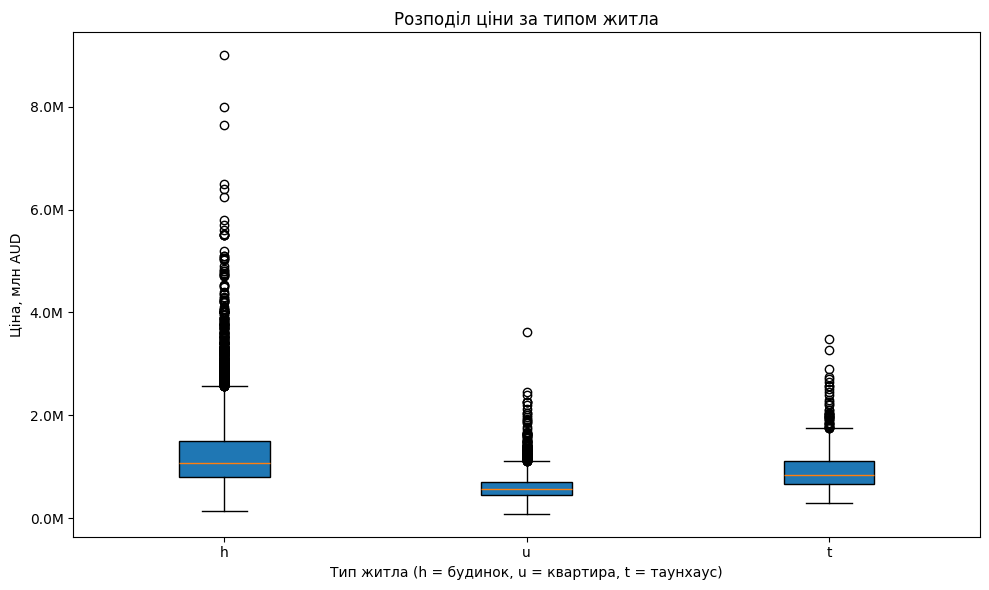

In [114]:
# Робимо графік "Ціна за типом житла (boxplot)"
fig, ax = plt.subplots(figsize=(10, 6))

types = df["Type"].unique()
data_by_type = [df[df["Type"] == t]["Price"].dropna() for t in types]

ax.boxplot(data_by_type, tick_labels=types, patch_artist=True)

ax.set_title("Розподіл ціни за типом житла")
ax.set_xlabel("Тип житла (h = будинок, u = квартира, t = таунхаус)")  # підпис осі X
ax.set_ylabel("Ціна, млн AUD")                                          # підпис осі Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()



(array([1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(1, 0, 'Northern Metropolitan'),
  Text(2, 0, 'Western Metropolitan'),
  Text(3, 0, 'Southern Metropolitan'),
  Text(4, 0, 'Eastern Metropolitan'),
  Text(5, 0, 'South-Eastern Metropolitan'),
  Text(6, 0, 'Eastern Victoria'),
  Text(7, 0, 'Northern Victoria'),
  Text(8, 0, 'Western Victoria')])

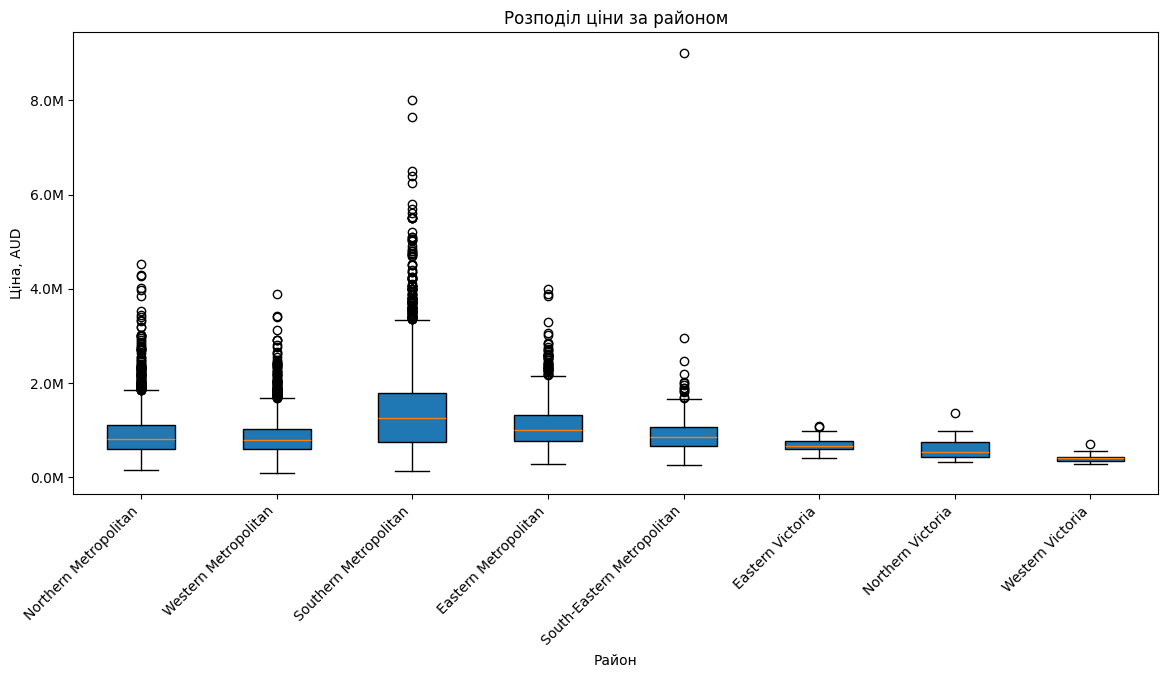

In [115]:
# Робимо графік "Ціна за районом (boxplot)"
fig, ax = plt.subplots(figsize=(14, 6))

regions = df["Regionname"].dropna().unique()
data_by_region = [df[df["Regionname"] == r]["Price"].dropna() for r in regions]

ax.boxplot(data_by_region, tick_labels=regions, patch_artist=True)
ax.set_title("Розподіл ціни за районом")
ax.set_xlabel("Район")
ax.set_ylabel("Ціна, AUD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45, ha="right")

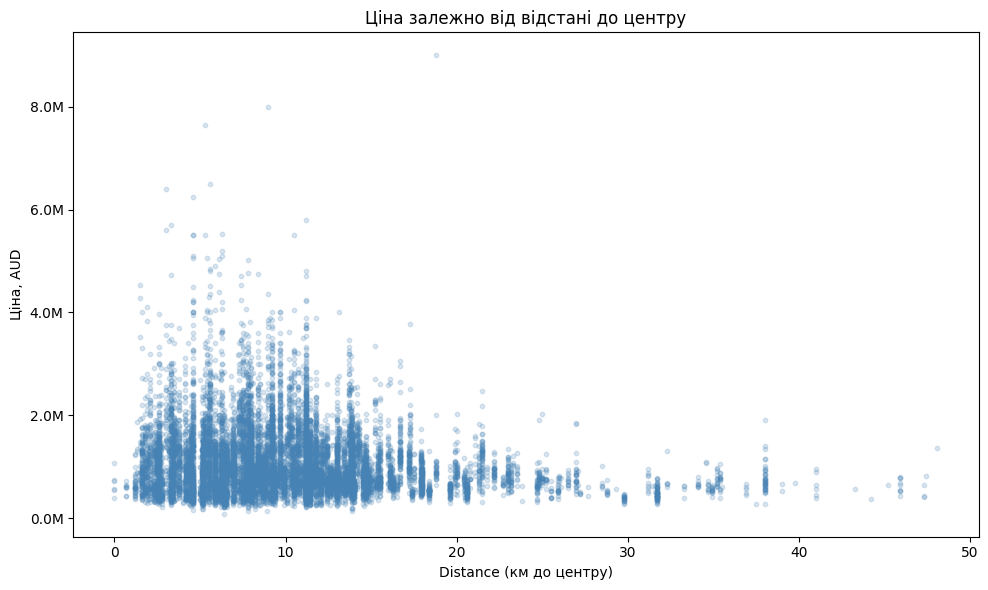

In [116]:
# Робимо графік "Scatter: ціна vs відстань"
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df["Distance"], df["Price"], alpha=0.2, s=10, color="steelblue")
ax.set_title("Ціна залежно від відстані до центру")
ax.set_xlabel("Distance (км до центру)")
ax.set_ylabel("Ціна, AUD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()


In [117]:
# кореляція числових ознак ІЗ ЦІНОЮ:
num = df.select_dtypes("number")
cor_price = num.corr()["Price"].drop("Price")
print(cor_price.sort_values(key=abs, ascending=False).round(3))

Rooms            0.497
Bedroom2         0.476
Bathroom         0.467
YearBuilt       -0.324
Car              0.239
Lattitude       -0.213
Longtitude       0.204
Distance        -0.163
Postcode         0.108
BuildingArea     0.091
Propertycount   -0.042
Landsize         0.038
Name: Price, dtype: float64


In [118]:
# пошук майже-дублікатів
cm = num.corr().abs()
for col in cm.columns:
    for row in cm.index:
        if col != row and cm.loc[row, col] > 0.9:
            print(f"{row} ↔ {col}: {cm.loc[row, col]:.3f}")


Bedroom2 ↔ Rooms: 0.944
Rooms ↔ Bedroom2: 0.944


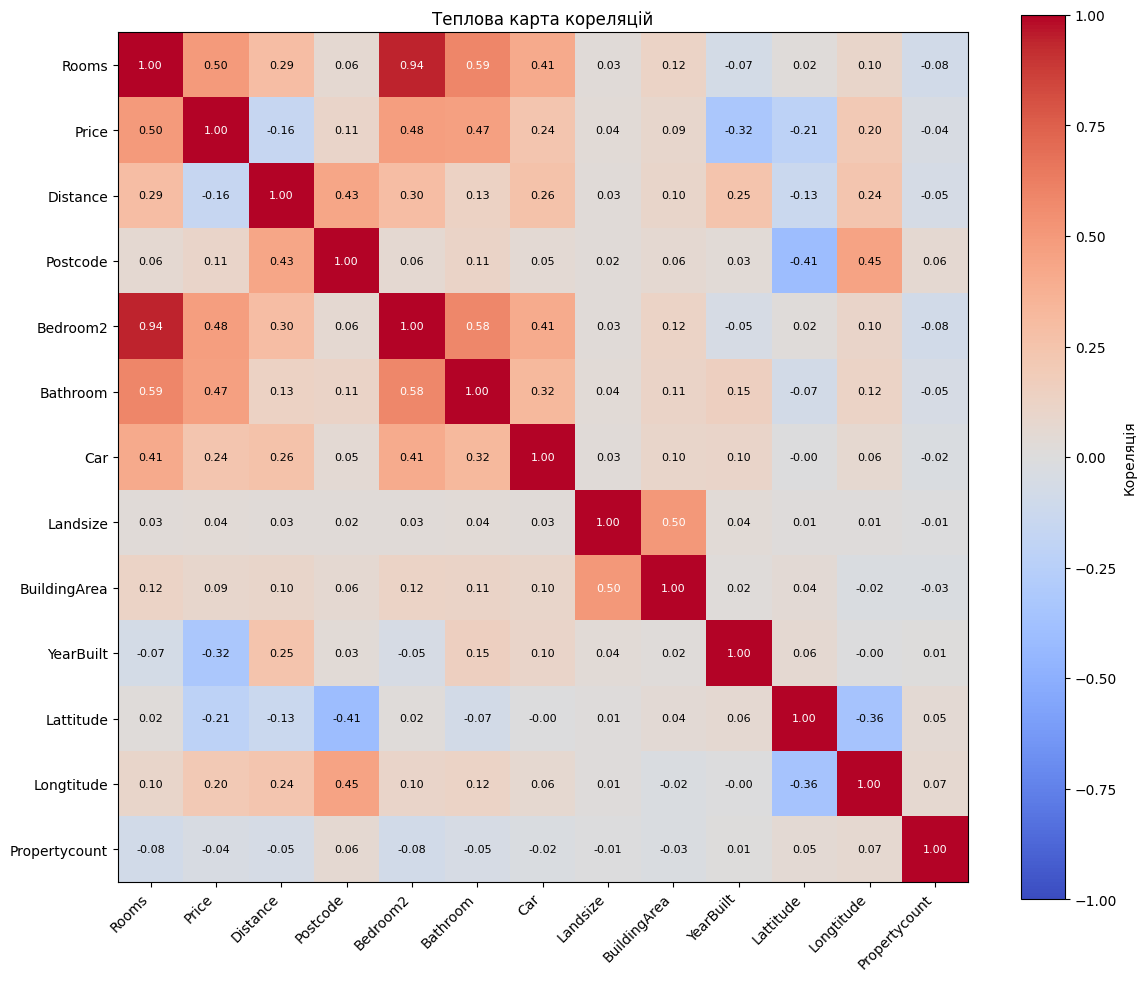

In [119]:
# Робимо Теплову карту кореляцій
fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = num.corr()
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Підписи осей
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# Числа у клітинках
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, label="Кореляція")
ax.set_title("Теплова карта кореляцій")
plt.tight_layout()
plt.show()

**ВИСНОВОК:**
1. Тип житла суттєво впливає на ціну

Будинки (h) — найдорожчі, їх медіана близько 1 млн AUD. Квартири (u) — вдвічі дешевші, медіана близько 550 тисяч. Таунхауси (t) — посередині, близько 900 тисяч. Тому стовпець Type обов'язково включаємо в модель — він дає їй важливу підказку про ціну.    

2. Чим далі від центру — тим дешевше

Scatter-графік показав чіткий обернений зв'язок: об'єкти поблизу центру міста коштують значно дорожче, а зі збільшенням відстані ціна падає. Кореляція Distance з ціною від'ємна (~-0.28) — це помірний, але стабільний зв'язок. Ознаку Distance теж включаємо в модель.    

3. Rooms і Bedroom2 майже дублюють одна одну

Кореляція між цими двома стовпцями ~0.944 — вони несуть майже однакову інформацію. Тримати обидва немає сенсу — на кроці підготовки до моделі видалимо Bedroom2 і залишимо Rooms, бо він більш загальний (враховує всі кімнати, а не тільки спальні).

## Крок 5. Нові ознаки (feature engineering)

In [120]:
# Робимо копію, щоб clean з очищеними даними залишився недоторканим. Якщо щось піде не так з новими ознаками — повертаємось до clean і починаємо крок заново.
fe = clean.copy()
print("Копію створено. Розмір:", fe.shape)

Копію створено. Розмір: (13580, 21)


In [121]:
# витягуємо з дати окремо рік і місяць. Модель не вміє читати дату як об'єкт — їй потрібні числа.
fe["sale_year"]  = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

print(fe[["Date", "sale_year", "sale_month"]].head())

        Date  sale_year  sale_month
0 2016-12-03       2016          12
1 2016-02-04       2016           2
2 2017-03-04       2017           3
3 2017-03-04       2017           3
4 2016-06-04       2016           6


In [122]:
# Рахуємо скільки років будинку на момент продажу.
fe["age"] = fe["sale_year"] - fe["YearBuilt"]

# Підстраховка: від'ємний вік — помилка даних, замінюємо на NaN
fe.loc[fe["age"] < 0, "age"] = np.nan

print(fe[["sale_year", "YearBuilt", "age"]].dropna().head(10))
print("\nСтатистика age:")
print(fe["age"].describe().round(1))

    sale_year  YearBuilt    age
1        2016     1900.0  116.0
2        2017     1900.0  117.0
4        2016     2014.0    2.0
6        2016     1910.0  106.0
7        2016     1890.0  126.0
9        2016     1900.0  116.0
11       2016     2005.0   11.0
12       2016     2009.0    7.0
15       2016     1890.0  126.0
16       2016     1880.0  136.0

Статистика age:
count    8198.0
mean       51.8
std        36.2
min         0.0
25%        18.0
50%        47.0
75%        76.0
max       186.0
Name: age, dtype: float64


In [123]:
# Прапорці наявності даних
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"]    = fe["YearBuilt"].notna().astype(int)

print("has_buildingarea:", fe["has_buildingarea"].value_counts().to_dict())
print("has_yearbuilt:   ", fe["has_yearbuilt"].value_counts().to_dict())

has_buildingarea: {1: 7113, 0: 6467}
has_yearbuilt:    {1: 8204, 0: 5376}


In [124]:
# Частотне кодування району
print("Унікальних Suburb:", fe["Suburb"].nunique())

fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())

print("\nПриклад:")
print(fe[["Suburb", "suburb_freq"]].head(10))
print("\nСтатистика suburb_freq:")
print(fe["suburb_freq"].describe().round(0))

Унікальних Suburb: 314

Приклад:
       Suburb  suburb_freq
0  Abbotsford           56
1  Abbotsford           56
2  Abbotsford           56
3  Abbotsford           56
4  Abbotsford           56
5  Abbotsford           56
6  Abbotsford           56
7  Abbotsford           56
8  Abbotsford           56
9  Abbotsford           56

Статистика suburb_freq:
count    13580.0
mean       113.0
std         79.0
min          1.0
25%         51.0
50%        102.0
75%        162.0
max        359.0
Name: suburb_freq, dtype: float64


In [125]:
# Видаляємо зайві стовпці
cols_to_drop = [
    "Date",      # вже витягли sale_year і sale_month
    "YearBuilt", # вже порахували age
    "Suburb",    # вже закодували через suburb_freq
    "Address",   # унікальний текст — модель нічому не навчиться
    "SellerG",   # агент продажу — занадто багато унікальних значень
    "Bedroom2",  # майже дублює Rooms (кореляція ~0.94 — знайшли на кроці EDA)
]

fe = fe.drop(columns=cols_to_drop)

print("Стовпці після видалення:")
for col in fe.columns:
    print(f"  {col}")
print("\nРозмір:", fe.shape)

Стовпці після видалення:
  Rooms
  Type
  Price
  Method
  Distance
  Postcode
  Bathroom
  Car
  Landsize
  BuildingArea
  CouncilArea
  Lattitude
  Longtitude
  Regionname
  Propertycount
  sale_year
  sale_month
  age
  has_buildingarea
  has_yearbuilt
  suburb_freq

Розмір: (13580, 21)


## Крок 6. Підготовка до моделювання

In [126]:
# 1. Імпорти
from sklearn.model_selection import train_test_split  # ділить дані на навчальну і тестову частиниColumnTransformerзастосовує різну підготовку до різних стовпців
from sklearn.compose import ColumnTransformer # застосовує різну підготовку до різних стовпців
from sklearn.pipeline import Pipeline # склеює кілька кроків підготовки в один об'єкт
from sklearn.impute import SimpleImputer # заповнює пропуски (медіаною або найчастішим значенням)
from sklearn.preprocessing import OneHotEncoder # перетворює текстові категорії на числові стовпці 0/1

RANDOM_STATE = 42

# Ціль — те, що прогнозуємо
y = fe["Price"]

# Ознаки — все інше (без Price)
X = fe.drop(columns=["Price"])

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)
print("\nСтовпці X:")
print(X.dtypes)

Розмір X: (13580, 20)
Розмір y: (13580,)

Стовпці X:
Rooms                 int64
Type                 object
Method               object
Distance            float64
Postcode            float64
Bathroom            float64
Car                 float64
Landsize            float64
BuildingArea        float64
CouncilArea          object
Lattitude           float64
Longtitude          float64
Regionname           object
Propertycount       float64
sale_year             int32
sale_month            int32
age                 float64
has_buildingarea      int64
has_yearbuilt         int64
suburb_freq           int64
dtype: object


In [127]:
# Ділимо стовпці на числові і категорійні

# Категорійні стовпці (текст)
cat_cols = ["Type", "Method", "Regionname", "CouncilArea"]

# Числові стовпці — все інше в X
num_cols = [col for col in X.columns if col not in cat_cols]

print("Категорійні стовпці:", cat_cols)
print("\nЧислові стовпці:", num_cols)
print(f"\nВсього: {len(cat_cols)} категорійних + {len(num_cols)} числових = {len(cat_cols)+len(num_cols)} стовпців")

Категорійні стовпці: ['Type', 'Method', 'Regionname', 'CouncilArea']

Числові стовпці: ['Rooms', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Lattitude', 'Longtitude', 'Propertycount', 'sale_year', 'sale_month', 'age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']

Всього: 4 категорійних + 16 числових = 20 стовпців


In [128]:
#  Будуємо конвеєр підготовки

# Підготовка числових стовпців
num_transformer = SimpleImputer(strategy="median")

# Підготовка категорійних стовпців (два кроки в одному Pipeline)
cat_transformer = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Об'єднуємо в один ColumnTransformer
preprocess = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
])

print("Конвеєр підготовки побудовано!")
print("\nЧислові стовпці -> заповнення медіаною")
print("Категорійні стовпці -> заповнення модою -> One-Hot кодування")

Конвеєр підготовки побудовано!

Числові стовпці -> заповнення медіаною
Категорійні стовпці -> заповнення модою -> One-Hot кодування


In [129]:
# # Підготовка числових стовпців
num_transformer = SimpleImputer(strategy="median")

# Підготовка категорійних стовпців (два кроки в одному Pipeline)
cat_transformer = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Об'єднуємо в один ColumnTransformer
preprocess = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols),
])

print("Конвеєр підготовки побудовано!")
print("\nЧислові стовпці → заповнення медіаною")
print("Категорійні стовпці → заповнення модою → One-Hot кодування")

Конвеєр підготовки побудовано!

Числові стовпці → заповнення медіаною
Категорійні стовпці → заповнення модою → One-Hot кодування


In [130]:
# Ділимо на train і test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Розмір навчальної вибірки (train):")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")

print("\nРозмір тестової вибірки (test):")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

print(f"\nТrain: {len(X_train)/len(X)*100:.0f}% даних")
print(f"Test:  {len(X_test)/len(X)*100:.0f}% даних")

Розмір навчальної вибірки (train):
  X_train: (10864, 20), y_train: (10864,)

Розмір тестової вибірки (test):
  X_test: (2716, 20), y_test: (2716,)

Тrain: 80% даних
Test:  20% даних


## Крок 7. Модель і прогноз

In [131]:
# Імпорти
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Імпорти готові!")

Імпорти готові!


In [145]:
# Функція оцінки моделі
def evaluate(model, name):
    pipe = Pipeline([
       ("prep", preprocess),
       ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)

    print(f"\n{'='*40}")
    print(f"Модель: {name}")
    print(f"{'='*40}")
    print(f"MAE  = {mae:>12,.0f} AUD  (середня помилка)")
    print(f"RMSE = {rmse:>12,.0f} AUD  (помилка з карою за великі промахи)")
    print(f"R²   = {r2:>12.3f}      (1.0 = ідеально, 0 = не краще за середнє)")

    return pipe

In [146]:
# Базова лінія (Dummy)
pipe_dummy = evaluate(
    DummyRegressor(strategy="mean"),
    "Базова лінія (завжди середнє)"
)


Модель: Базова лінія (завжди середнє)
MAE  =      461,258 AUD  (середня помилка)
RMSE =      630,259 AUD  (помилка з карою за великі промахи)
R²   =       -0.000      (1.0 = ідеально, 0 = не краще за середнє)


In [147]:
# Лінійна регресія
pipe_lr = evaluate(
    LinearRegression(),
    "Лінійна регресія"
)


Модель: Лінійна регресія
MAE  =      256,139 AUD  (середня помилка)
RMSE =      372,709 AUD  (помилка з карою за великі промахи)
R²   =        0.650      (1.0 = ідеально, 0 = не краще за середнє)


In [148]:
# Випадковий ліс
pipe_rf = evaluate(
    RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "Випадковий ліс"
)


Модель: Випадковий ліс
MAE  =      162,328 AUD  (середня помилка)
RMSE =      269,297 AUD  (помилка з карою за великі промахи)
R²   =        0.817      (1.0 = ідеально, 0 = не краще за середнє)


In [149]:
# Порівняння моделей
print("\n" + "="*55)
print("ПОРІВНЯННЯ МОДЕЛЕЙ")
print("="*55)
print(f"{'Модель':<30} {'MAE':>10} {'R²':>8}")
print("-"*55)

results = [
    ("Базова лінія", pipe_dummy),
    ("Лінійна регресія", pipe_lr),
    ("Випадковий ліс", pipe_rf),
]

for name, pipe in results:
    pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2  = r2_score(y_test, pred)
    print(f"{name:<30} {mae:>10,.0f} {r2:>8.3f}")

print("="*55)
print("Чим менше MAE і чим ближче R² до 1.0 — тим краще")


ПОРІВНЯННЯ МОДЕЛЕЙ
Модель                                MAE       R²
-------------------------------------------------------
Базова лінія                      461,258   -0.000
Лінійна регресія                  256,139    0.650
Випадковий ліс                    162,328    0.817
Чим менше MAE і чим ближче R² до 1.0 — тим краще


=== ТОП-15 НАЙВАЖЛИВІШИХ ОЗНАК ===

                          ознака  важливість
Regionname_Southern Metropolitan    0.208618
                           Rooms    0.173989
                        Distance    0.135918
                          Type_u    0.088964
                        Landsize    0.078852
                      Longtitude    0.052608
                    BuildingArea    0.046080
                       Lattitude    0.042210
                        Bathroom    0.030561
                             age    0.025720
                   Propertycount    0.017325
 Regionname_Eastern Metropolitan    0.013927
                      sale_month    0.013816
                        Postcode    0.012425
                     suburb_freq    0.010449


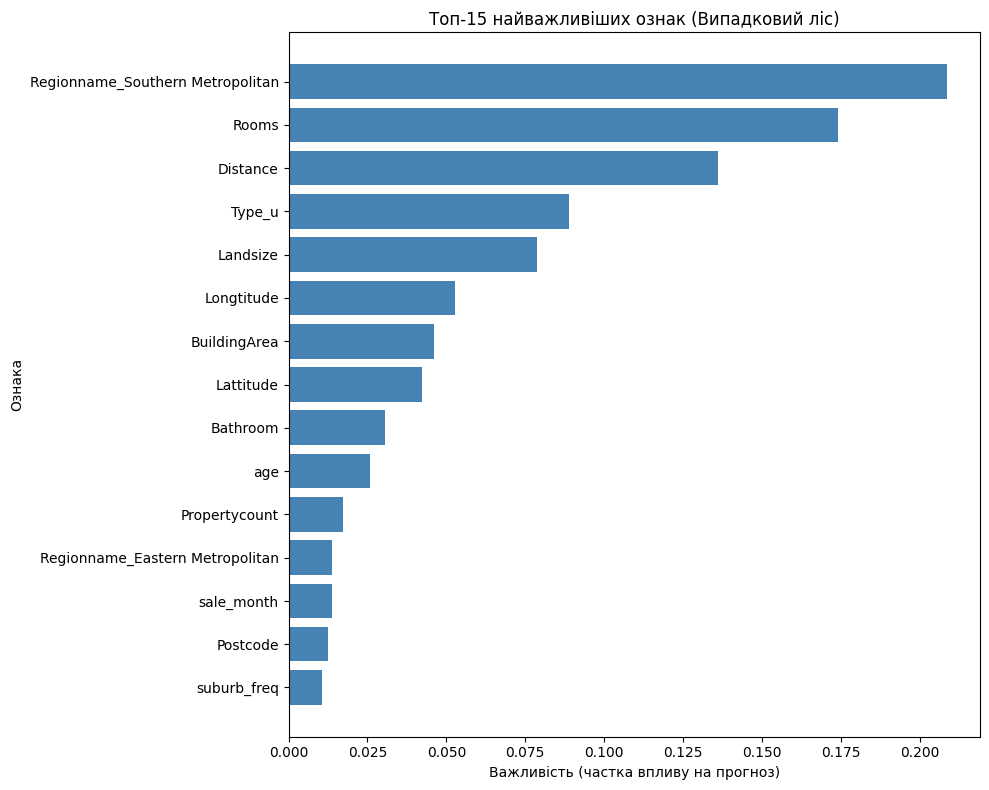

In [150]:
# Важливість ознак лісу
# Дістаємо модель з конвеєра
rf_model = pipe_rf.named_steps["model"]

# Дістаємо назви стовпців після всіх перетворень
feature_names = (
    num_cols +
    list(pipe_rf.named_steps["prep"]
         .named_transformers_["cat"]
         .named_steps["ohe"]
         .get_feature_names_out(cat_cols))
)

# Збираємо важливість ознак у таблицю
importances = pd.DataFrame({
    "ознака": feature_names,
    "важливість": rf_model.feature_importances_
}).sort_values("важливість", ascending=False)

print("=== ТОП-15 НАЙВАЖЛИВІШИХ ОЗНАК ===\n")
print(importances.head(15).to_string(index=False))

# Графік
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
top15 = importances.head(15)
ax.barh(top15["ознака"][::-1], top15["важливість"][::-1], color="steelblue")
ax.set_title("Топ-15 найважливіших ознак (Випадковий ліс)")
ax.set_xlabel("Важливість (частка впливу на прогноз)")
ax.set_ylabel("Ознака")
plt.tight_layout()
plt.show()

In [151]:
#  Прогноз для одного будинку
# Беремо один реальний будинок з тестової вибірки
idx = 0
one_house = X_test.iloc[[idx]]   # подвійні дужки [[]] — щоб отримати DataFrame, а не Series
real_price = y_test.iloc[idx]

# Прогнозуємо ціну
predicted_price = pipe_rf.predict(one_house)[0]

print("=== ПРОГНОЗ ДЛЯ ОДНОГО БУДИНКУ ===\n")
print("Характеристики будинку:")
print(one_house.T.to_string())   # .T — транспонуємо для зручного читання

print(f"\nРеальна ціна:      {real_price:>12,.0f} AUD")
print(f"Прогноз моделі:    {predicted_price:>12,.0f} AUD")
print(f"Помилка:           {abs(real_price - predicted_price):>12,.0f} AUD")
print(f"Помилка %:         {abs(real_price - predicted_price)/real_price*100:>11.1f} %")

=== ПРОГНОЗ ДЛЯ ОДНОГО БУДИНКУ ===

Характеристики будинку:
                                   1061
Rooms                                 3
Type                                  h
Method                                S
Distance                           11.2
Postcode                         3186.0
Bathroom                            2.0
Car                                 3.0
Landsize                          588.0
BuildingArea                        NaN
CouncilArea                     Bayside
Lattitude                      -37.9287
Longtitude                      144.992
Regionname        Southern Metropolitan
Propertycount                   10579.0
sale_year                          2016
sale_month                            8
age                                 NaN
has_buildingarea                      0
has_yearbuilt                         0
suburb_freq                         186

Реальна ціна:         2,600,000 AUD
Прогноз моделі:       2,128,685 AUD
Помилка:                471